In [11]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import tensorflow as tf
import autokeras as ak
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [12]:
# Cell 2: Data Loading and Preprocessing
# Load the datasets
df_hemo = pd.read_csv(os.path.expanduser('~/merged_hemorrhage_embeddings.csv'))
df_control = pd.read_csv(os.path.expanduser('~/merged_control_embeddings.csv'))

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# Extract features and labels
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data (20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)


X_train_scaled shape: (12900, 1408)
y_train shape: (12900, 6)


In [13]:
# Cell 3: Define the Competition Loss Function
class CompetitionLogLoss(tf.keras.losses.Loss):
    def __init__(self, any_weight=2.0, epsilon=1e-15, name='comp_log_loss'):
        super().__init__(name=name)
        self.any_weight = any_weight
        self.epsilon = epsilon

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, self.epsilon, 1 - self.epsilon)
        log_loss = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        weights = tf.concat([
            tf.ones((tf.shape(y_true)[0], 1)) * self.any_weight,
            tf.ones((tf.shape(y_true)[0], tf.shape(y_true)[1]-1))
        ], axis=1)
        return tf.reduce_mean(log_loss * weights)

# Instantiate the loss function
comp_loss = CompetitionLogLoss(any_weight=2.0, epsilon=1e-15)


In [26]:
# Cell 4: Define Custom Block (Revised)
from autokeras.engine import block as ak_block
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2

# Cell 4: Define Custom Model Block
from autokeras.engine import block as ak_block
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

class CustomDenseBlock(ak_block.Block):
    def build(self, hp, inputs=None):
        input_node = inputs[0] if isinstance(inputs, list) else inputs
        x = input_node

        # First dense layer
        x = Dense(units=hp.Int('units_0', 32, 256, step=32),
                  activation='relu',
                  kernel_regularizer=l2(hp.Float('l2_0', 1e-5, 1e-2, sampling='log')))(x)
        x = BatchNormalization()(x)
        x = Dropout(hp.Float('dropout_0', 0, 0.5, step=0.1))(x)

        # Second dense layer
        x = Dense(units=hp.Int('units_1', 32, 128, step=32),
                  activation='relu',
                  kernel_regularizer=l2(hp.Float('l2_1', 1e-5, 1e-2, sampling='log')))(x)
        x = BatchNormalization()(x)
        x = Dropout(hp.Float('dropout_1', 0, 0.5, step=0.1))(x)
        
        return x


In [30]:
from autokeras.engine import block as ak_block
import tensorflow.keras.backend as K
import tensorflow as tf
# Cell 4: Define Custom Model Block
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2


# Ensure compatibility by flattening input nodes later via tf.nest.flatten if needed.
class CustomDenseBlock(ak_block.Block):
    def build(self, hp, inputs=None):
        input_node = tf.nest.flatten(inputs)[0] if inputs is not None else None
        x = input_node
        
        # First dense layer hyperparameters:
        units0 = hp.Int('units_0', min_value=64, max_value=256, step=32, default=128)
        l2_0 = hp.Float('l2_0', min_value=1e-5, max_value=1e-2, sampling='log', default=1e-3)
        dropout0 = hp.Float('dropout_0', min_value=0.0, max_value=0.5, step=0.1, default=0.25)
        activation0 = 'relu'
        
        x = layers.Dense(units0, activation=activation0, kernel_regularizer=l2(l2_0))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout0)(x)
        
        # Define reduction factor so that the second layer is a fraction of the first.
        reduction_factor = hp.Float('reduction_factor', min_value=0.25, max_value=0.75, default=0.5)
        units1 = int(units0 * reduction_factor)
        
        l2_1 = hp.Float('l2_1', min_value=1e-5, max_value=1e-2, sampling='log', default=1e-3)
        dropout1 = hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1, default=0.25)
        activation1 = 'relu'
        
        x = layers.Dense(units1, activation=activation1, kernel_regularizer=l2(l2_1))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout1)(x)
        
        return x



In [35]:
import tensorflow as tf
from tensorflow.keras import layers
from autokeras.engine import head as ak_head

class RegressionHeadSigmoidWithTemp(ak.RegressionHead):
    def __init__(self, output_dim=6, temperature=0.5, **kwargs):
        # Force the head name to be 'sigmoid'
        kwargs['name'] = 'sigmoid'
        super().__init__(**kwargs)
        self.output_dim = output_dim
        self.temperature = temperature

    def build(self, hp, inputs=None):
        # Manually flatten inputs and ensure we have exactly one input node.
        inputs = tf.nest.flatten(inputs)
        if len(inputs) != 1:
            raise ValueError(f"Expected exactly one input but got {len(inputs)}")
        input_node = inputs[0]
        
        # Use hyperparameter for the dropout rate if needed.
        dropout_rate = hp.Choice('head_dropout_rate', [0.0, 0.25, 0.5], default=0.0)
        if dropout_rate > 0:
            input_node = layers.Dropout(dropout_rate)(input_node)
        
        # Flatten if needed.
        input_node = layers.Flatten()(input_node)
        # Create the final dense layer without activation.
        logits = layers.Dense(self.output_dim, activation=None, name=self.name)(input_node)
        # Apply temperature scaling: dividing logits by temperature makes the sigmoid steeper.
        scaled_logits = logits / self.temperature
        # Finally, apply the sigmoid activation.
        output_node = layers.Activation('sigmoid')(scaled_logits)
        return output_node


In [36]:
# Define the input node (shape according to the preprocessed data).
input_node = ak.Input(shape=(X_train_scaled.shape[1],))
# Pass through the custom dense block for feature extraction.
dense_output = CustomDenseBlock()(input_node)
# Pass the intermediate features through your custom regression head.
output_node = RegressionHeadSigmoidWithTemp()(dense_output)

# Build the AutoKeras model.
model = ak.AutoModel(
    inputs=input_node,
    outputs=output_node,
    overwrite=True,
    max_trials=40,   # Increase as needed.
    tuner='bayesian'
)


In [37]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    callbacks=callbacks
)


Trial 2 Complete [00h 00m 01s]

Best val_loss So Far: None
Total elapsed time: 00h 00m 01s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
64                |96                |custom_dense_block_1/units_0
1.1894e-05        |0.0068435         |custom_dense_block_1/l2_0
0.2               |0.3               |custom_dense_block_1/dropout_0
0.28631           |0.40561           |custom_dense_block_1/reduction_factor
0.005879          |8.2171e-05        |custom_dense_block_1/l2_1
0                 |0.3               |custom_dense_block_1/dropout_1
0.5               |0.25              |sigmoid/head_dropout_rate
sgd               |adam_weight_decay |optimizer
0.1               |0.01              |learning_rate

Epoch 1/100


Traceback (most recent call last):
  File "/home/bahram/.local/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/home/bahram/.local/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/home/bahram/.local/lib/python3.10/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "/home/bahram/.local/lib/python3.10/site-packages/autokeras/engine/tuner.py", line 102, in _build_and_fit_model
    _, history = utils.fit_with_adaptive_batch_size(
  File "/home/bahram/.local/lib/python3.10/site-packages/autokeras/utils/utils.py", line 69, in fit_with_adaptive_batch_size
    history = run_with_adaptive_batch_size(
  File "/home/bahram/.local/lib/python3.10/site

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "/home/bahram/.local/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "/home/bahram/.local/lib/python3.10/site-packages/keras_tuner/src/engine/base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
  File "/home/bahram/.local/lib/python3.10/site-packages/keras_tuner/src/engine/tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
  File "/home/bahram/.local/lib/python3.10/site-packages/autokeras/engine/tuner.py", line 102, in _build_and_fit_model
    _, history = utils.fit_with_adaptive_batch_size(
  File "/home/bahram/.local/lib/python3.10/site-packages/autokeras/utils/utils.py", line 69, in fit_with_adaptive_batch_size
    history = run_wit

In [27]:
best_model = model.export_model()
best_model.summary()

# Compile with your competition loss function and a standard optimizer.
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=comp_loss,
    metrics=['accuracy']
)

# Evaluate on the test set.
test_loss, test_accuracy = best_model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions.
y_pred = best_model.predict(X_test_scaled)

# Display sample predictions.
print("\nSample Predictions (values between 0 and 1):")
for i in range(5):
    print(f"Sample {i+1}:")
    for j, col in enumerate(target_columns):
        print(f"  {col}: {y_pred[i][j]:.4f}")
    print()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        45,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_head_sigmoid_1       │ (None, 6)              │           774 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,726 (198.15 KB)

 Trainable params: 50,406 (196.90 KB)

 Non-trainable params: 320 (1.25 KB)

101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9905 - loss: 0.4004 
Test Loss: 0.4036
Test Accuracy: 0.9922
 17/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   

/home/bahram/.local/lib/python3.10/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 1408))
  warnings.warn(msg)


101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Sample Predictions (values between 0 and 1):
Sample 1:
  any: 0.7547
  epidural: 0.0281
  intraparenchymal: 0.4315
  intraventricular: 0.3047
  subarachnoid: 0.3241
  subdural: 0.3161

Sample 2:
  any: 0.6793
  epidural: 0.0322
  intraparenchymal: 0.3928
  intraventricular: 0.2845
  subarachnoid: 0.3029
  subdural: 0.2993

Sample 3:
  any: 0.1451
  epidural: 0.0069
  intraparenchymal: 0.0972
  intraventricular: 0.0718
  subarachnoid: 0.0734
  subdural: 0.0741

Sample 4:
  any: 0.7818
  epidural: 0.0260
  intraparenchymal: 0.4609
  intraventricular: 0.3286
  subarachnoid: 0.3490
  subdural: 0.3473

Sample 5:
  any: 0.9666
  epidural: 0.0112
  intraparenchymal: 0.5980
  intraventricular: 0.4228
  subarachnoid: 0.4278
  subdural: 0.4402



NameError: name 'history' is not defined

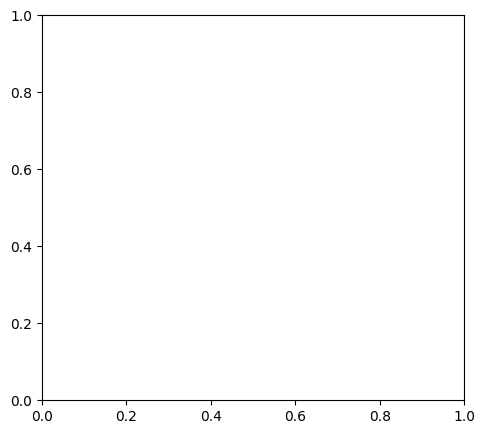

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

if 'accuracy' in history.history:
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

plt.tight_layout()
plt.show()
